<a href="https://colab.research.google.com/github/VagrantTrack149/Verano-espectroscopia-ia/blob/main/Procesamiento_info.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Librerías necesarias

In [ ]:
import sys
!{sys.executable} -m pip install scikit-optimize

import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import plotly.express as px
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

from skopt import BayesSearchCV
from skopt.space import Integer,Real, Categorical

# Ignorar warnings molestos
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.7 MB/s eta 0:00:00


## Carga de datos

In [ ]:
df = pd.read_csv("data/datos_hojas_procesado.csv", index_col=0)

# Codificar etiquetas
le = LabelEncoder()
df["etiqueta_encoded"] = le.fit_transform(df["etiqueta"])

# Balancear clases
min_count = df["etiqueta_encoded"].value_counts().min()

# Tomar min_count muestras aleatorias por clase
df_balanced = (
    df.groupby("etiqueta_encoded", group_keys=False)
    .apply(lambda x: x.sample(n=min_count, random_state=42))
    .reset_index(drop=True)
)

# Separar características y etiquetas
X = df_balanced.drop(columns=["etiqueta", "etiqueta_encoded"])
y_encoded = df_balanced["etiqueta_encoded"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42
)


## Modelos de clasificación

=== LDA con hiperparámetros optimizados ===
              precision    recall  f1-score   support

hoja enferma       0.86      0.90      0.88        20
   hoja sana       0.88      0.71      0.79        21
   hoja seca       0.88      1.00      0.93        21

    accuracy                           0.87        62
   macro avg       0.87      0.87      0.87        62
weighted avg       0.87      0.87      0.87        62



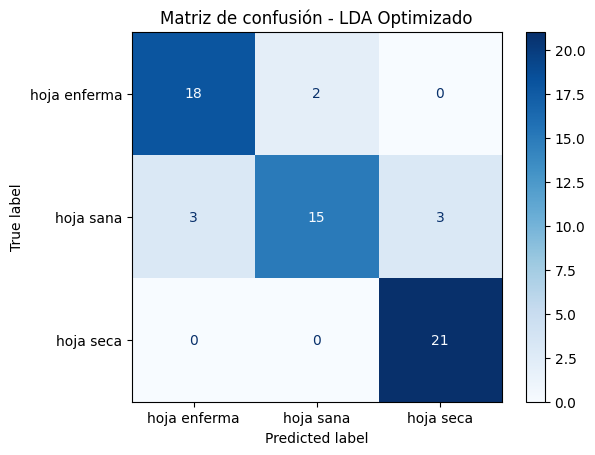

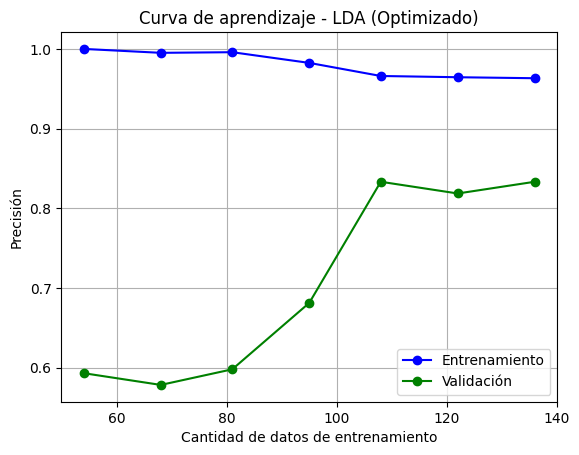

In [ ]:
# Asegurar que los datos están en formato correcto
X_train_np = np.asarray(X_train, dtype=np.float64)
X_test_np = np.asarray(X_test, dtype=np.float64)
X_all_np = np.asarray(X, dtype=np.float64)
y_all_np = np.asarray(y_encoded)

# # ------------------------------
# # Búsqueda Bayesiana de hiperparámetros para LDA con espacio condicional
# # ------------------------------
# search_spaces = [
#     ({'solver': Categorical(['svd'])}, 1),
#     ({
#         'solver': Categorical(['lsqr', 'eigen']),
#         'shrinkage': Real(0.0, 1.0, prior='uniform')
#     }, 3)
# ]

# cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# opt = BayesSearchCV(
#     estimator=LinearDiscriminantAnalysis(),
#     search_spaces=search_spaces,
#     n_iter=30,
#     cv=cv_strategy,
#     scoring='accuracy',
#     n_jobs=-1,
#     error_score=np.nan,
#     random_state=42
# )

# # Ajustar búsqueda al conjunto de entrenamiento
# opt.fit(X_train_np, y_train)

# # Mejor modelo encontrado
# lda_best = opt.best_estimator_

# # ------------------------------
# # Evaluar modelo optimizado
# # ------------------------------
# y_pred_lda = lda_best.predict(X_test_np)

# print("=== LDA Optimizado (Bayesian Search) ===")
# print("Mejores hiperparámetros encontrados:", opt.best_params_)
# print(classification_report(y_test, y_pred_lda, target_names=le.classes_))

# === LDA Optimizado (Bayesian Search) ===
# Mejores hiperparámetros encontrados:
# OrderedDict([('shrinkage', 0.44483251230115184), ('solver', 'eigen')])

# ------------------------------
# Modelo LDA directamente con hiperparámetros optimizados
# ------------------------------
lda_best = LinearDiscriminantAnalysis(solver='eigen', shrinkage=0.44483251230115184)

# Entrenar el modelo
lda_best.fit(X_train_np, y_train)

# Evaluar modelo
y_pred_lda = lda_best.predict(X_test_np)

print("=== LDA con hiperparámetros optimizados ===")
print(classification_report(y_test, y_pred_lda, target_names=le.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_lda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de confusión - LDA Optimizado")
plt.grid(False)
plt.show()

# ------------------------------
# Curva de aprendizaje
# ------------------------------
train_sizes, train_scores, test_scores = learning_curve(
    lda_best,
    X_all_np, y_all_np,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Entrenamiento')
plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Validación')
plt.title("Curva de aprendizaje - LDA (Optimizado)")
plt.xlabel("Cantidad de datos de entrenamiento")
plt.ylabel("Precisión")
plt.legend()
plt.grid(True)
plt.show()

              precision    recall  f1-score   support

hoja enferma       0.88      0.75      0.81        20
   hoja sana       0.82      0.86      0.84        21
   hoja seca       0.87      0.95      0.91        21

    accuracy                           0.85        62
   macro avg       0.86      0.85      0.85        62
weighted avg       0.86      0.85      0.85        62



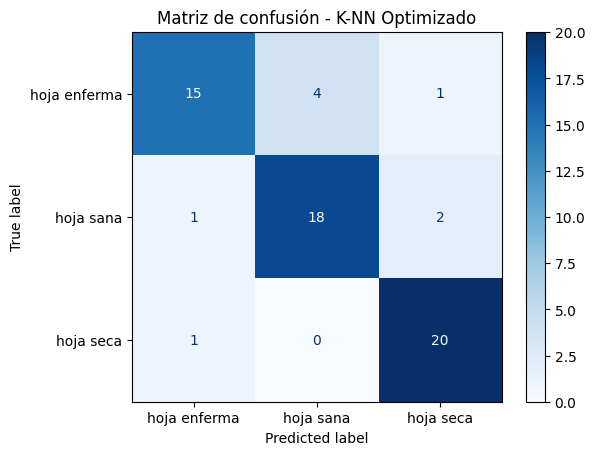

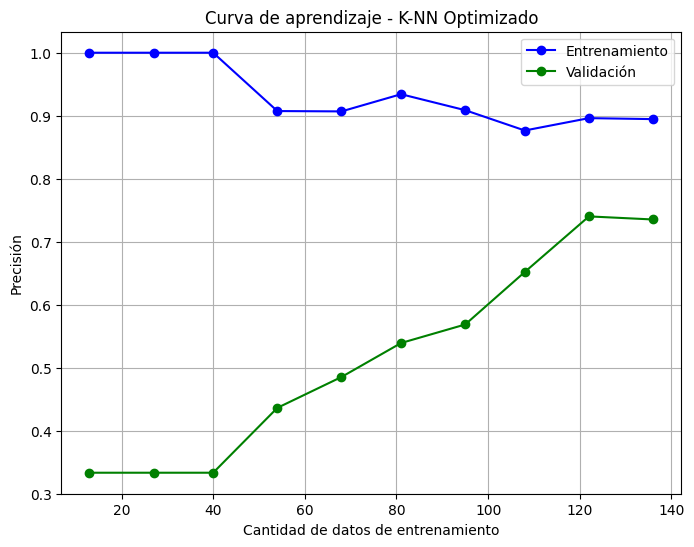

In [ ]:
# ------------------------------
# Conversión a NumPy
# ------------------------------
X_train_np = np.asarray(X_train, dtype=np.float64)
X_test_np = np.asarray(X_test, dtype=np.float64)
X_all_np = np.asarray(X, dtype=np.float64)
y_all_np = np.asarray(y_encoded)

# # ------------------------------
# # Búsqueda Bayesiana de hiperparámetros para K-NN
# # ------------------------------
# search_space_knn = {
#     'n_neighbors': Integer(1, 30),
#     'weights': Categorical(['uniform', 'distance']),
#     'p': Integer(1, 2)  # p=1: manhattan, p=2: euclidean
# }

# cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# opt_knn = BayesSearchCV(
#     estimator=KNeighborsClassifier(),
#     search_spaces=search_space_knn,
#     n_iter=30,
#     cv=cv_strategy,
#     scoring='accuracy',
#     n_jobs=-1,
#     random_state=42,
#     error_score=np.nan  # evita que errores detengan la búsqueda
# )

# # Ajustar la búsqueda al conjunto de entrenamiento
# opt_knn.fit(X_train_np, y_train)

# === K-NN Optimizado (Bayesian Search) ===
# Mejores hiperparámetros encontrados: OrderedDict([('n_neighbors', 1), ('p', 1), ('weights', 'distance')])
# SOBREAJUSTE

# Mejor modelo encontrado
knn_best = KNeighborsClassifier(n_neighbors=3, weights='uniform', p=1) # Empírico

# Entrenar el modelo
knn_best.fit(X_train_np, y_train)

# ------------------------------
# Evaluar modelo optimizado
# ------------------------------
y_pred_knn = knn_best.predict(X_test_np)

print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de confusión - K-NN Optimizado")
plt.grid(False)
plt.show()

# ------------------------------
# Curva de aprendizaje del mejor modelo
# ------------------------------
train_sizes, train_scores, test_scores = learning_curve(
    knn_best,
    X_all_np, y_all_np,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Entrenamiento')
plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Validación')
plt.title("Curva de aprendizaje - K-NN Optimizado")
plt.xlabel("Cantidad de datos de entrenamiento")
plt.ylabel("Precisión")
plt.legend()
plt.grid(True)
plt.show()


              precision    recall  f1-score   support

hoja enferma       1.00      0.95      0.97        20
   hoja sana       0.94      0.81      0.87        21
   hoja seca       0.84      1.00      0.91        21

    accuracy                           0.92        62
   macro avg       0.93      0.92      0.92        62
weighted avg       0.93      0.92      0.92        62



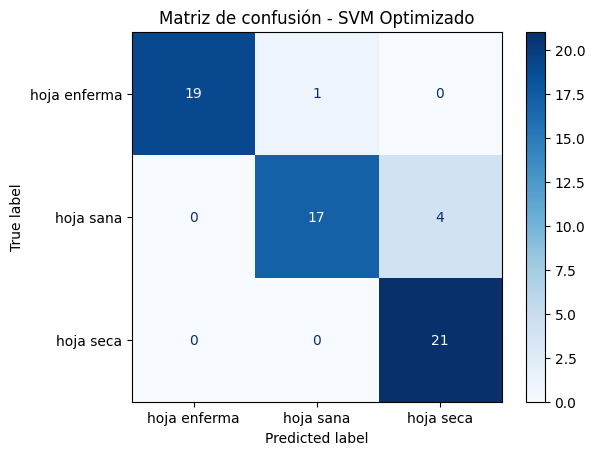

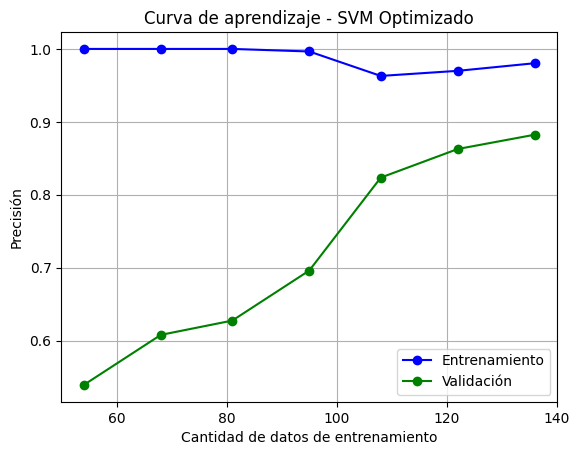

In [ ]:
# ------------------------------
# Asegurar formato correcto
# ------------------------------
X_train_np = np.asarray(X_train, dtype=np.float64)
X_test_np = np.asarray(X_test, dtype=np.float64)
X_all_np = np.asarray(X, dtype=np.float64)
y_all_np = np.asarray(y_encoded)

# # ------------------------------
# # Búsqueda bayesiana de hiperparámetros para SVM (RBF)
# # ------------------------------
# search_space_svm = {
#     'C': Real(1e-6, 1e2, prior='log-uniform'),
#     'gamma': Real(1e-6, 1e2, prior='log-uniform')
# }

# cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# opt_svm = BayesSearchCV(
#     estimator=SVC(kernel='rbf'),
#     search_spaces=search_space_svm,
#     n_iter=30,
#     cv=cv_strategy,
#     scoring='accuracy',
#     n_jobs=-1,
#     random_state=42,
#     error_score=np.nan
# )

# === SVM Optimizado (Bayesian Search) ===
# Mejores hiperparámetros encontrados: OrderedDict([('C', 46.571963541792634), ('gamma', 1e-06)])

# Mejor modelo encontrado
svm_best = SVC(kernel='rbf', C=46.571963541792634, gamma=1e-06)

# Entrenar el modelo
svm_best.fit(X_train_np, y_train)

# ------------------------------
# Evaluar modelo optimizado
# ------------------------------
y_pred_svm = svm_best.predict(X_test_np)
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de confusión - SVM Optimizado")
plt.grid(False)
plt.show()

# ------------------------------
# Curva de aprendizaje del mejor modelo
# ------------------------------
train_sizes, train_scores, test_scores = learning_curve(
    svm_best,
    X_all_np, y_all_np,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Entrenamiento')
plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Validación')
plt.title("Curva de aprendizaje - SVM Optimizado")
plt.xlabel("Cantidad de datos de entrenamiento")
plt.ylabel("Precisión")
plt.legend()
plt.grid(True)
plt.show()

=== Random Forest con búsqueda bayesiana ===
              precision    recall  f1-score   support

hoja enferma       1.00      0.90      0.95        20
   hoja sana       0.77      0.81      0.79        21
   hoja seca       0.77      0.81      0.79        21

    accuracy                           0.84        62
   macro avg       0.85      0.84      0.84        62
weighted avg       0.85      0.84      0.84        62



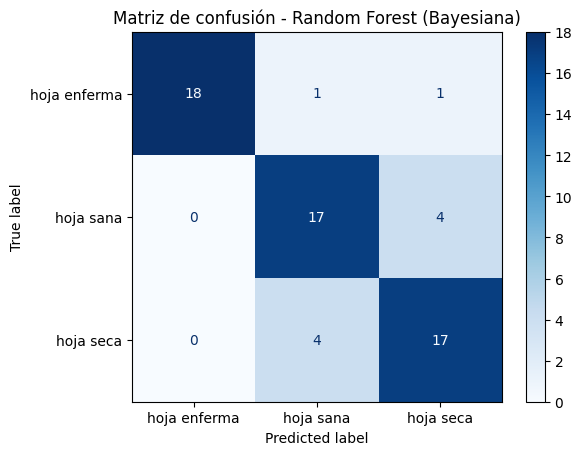

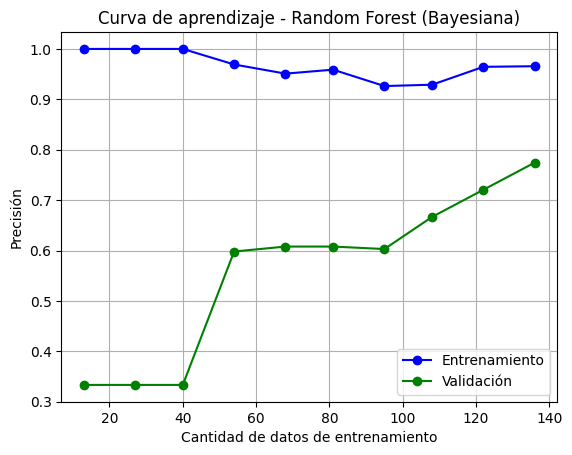

In [ ]:
# Asegurar datos en formato NumPy
X_train_np = np.asarray(X_train, dtype=np.float64)
X_test_np = np.asarray(X_test, dtype=np.float64)
X_all_np = np.asarray(X, dtype=np.float64)
y_all_np = np.asarray(y_encoded)

# # Definir espacio de búsqueda bayesiana para Random Forest
# search_spaces = {
#     'n_estimators': Integer(50, 300),
#     'max_depth': Integer(5, 50),
#     'min_samples_split': Integer(2, 10),
#     'min_samples_leaf': Integer(1, 10),
#     'max_features': Real(0.1, 1.0, prior='uniform')
# }

# # Configurar BayesSearchCV
# bayes_cv = BayesSearchCV(
#     estimator=RandomForestClassifier(random_state=42),
#     search_spaces=search_spaces,
#     n_iter=30,          # número de iteraciones de búsqueda
#     cv=5,
#     scoring='accuracy',
#     random_state=42,
#     n_jobs=-1,
#     verbose=0
# )

# # Entrenar con búsqueda bayesiana
# bayes_cv.fit(X_train_np, y_train)

# print("Mejores parámetros encontrados:")
# print(bayes_cv.best_params_)

# Mejores parámetros encontrados:
# OrderedDict([('max_depth', 12), ('max_features', 0.1), ('min_samples_leaf', 5), ('min_samples_split', 3), ('n_estimators', 50)])

best_rf = RandomForestClassifier(max_depth=12, max_features=0.1, min_samples_leaf=5, min_samples_split=3, n_estimators=50, random_state=42)

# Entrenar el modelo
best_rf.fit(X_train_np, y_train)

# Predicciones
y_pred_rf = best_rf.predict(X_test_np)

# === Reporte ===
print("=== Random Forest con búsqueda bayesiana ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# === Matriz de confusión ===
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de confusión - Random Forest (Bayesiana)")
plt.grid(False)
plt.show()

# === Curva de aprendizaje ===
train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X_all_np, y_all_np, cv=3, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Entrenamiento')
plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Validación')
plt.title("Curva de aprendizaje - Random Forest (Bayesiana)")
plt.xlabel("Cantidad de datos de entrenamiento")
plt.ylabel("Precisión")
plt.legend()
plt.grid(True)
plt.show()

## Análisis visual de datos

In [ ]:
# 1) Quitar filas con NaN
df_filtrado = df.dropna()

# 2) Separar X e y
X_filtrado = df_filtrado.drop(columns=["etiqueta"])
y_filtrado = df_filtrado["etiqueta"]

# 3) Codificar etiquetas
y_encoded_filtrado = le.transform(y_filtrado)

# 4) PCA con 3 componentes
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_filtrado)

# 5) Plot 3D
df3d = pd.DataFrame(
    X_pca, columns=["PC1","PC2","PC3"],
    index=df_filtrado.index
)
df3d["etiqueta"] = y_filtrado.values

fig = px.scatter_3d(
    df3d, x="PC1", y="PC2", z="PC3",
    color="etiqueta",
    title="PCA 3D interactivo",
    opacity=0.7
)

# 6) Ajustar tamaño de puntos
fig.update_traces(marker=dict(size=3))
fig.show()

Visualmente no existe una clara distinción entre los tres tipos de hojas. Sin embargo, se realizaron pruebas de clasificación con reducción de dimensionalidad usando sólo el rango visible (450nm -700nm) lo cuál empeoró los resultados, esto indica que la clasificación lograda es gracias a la amplia gama de características que se tienen en el conjunto de datos, y en este caso, PCA no es una buena opción.

## Índices vegetativos

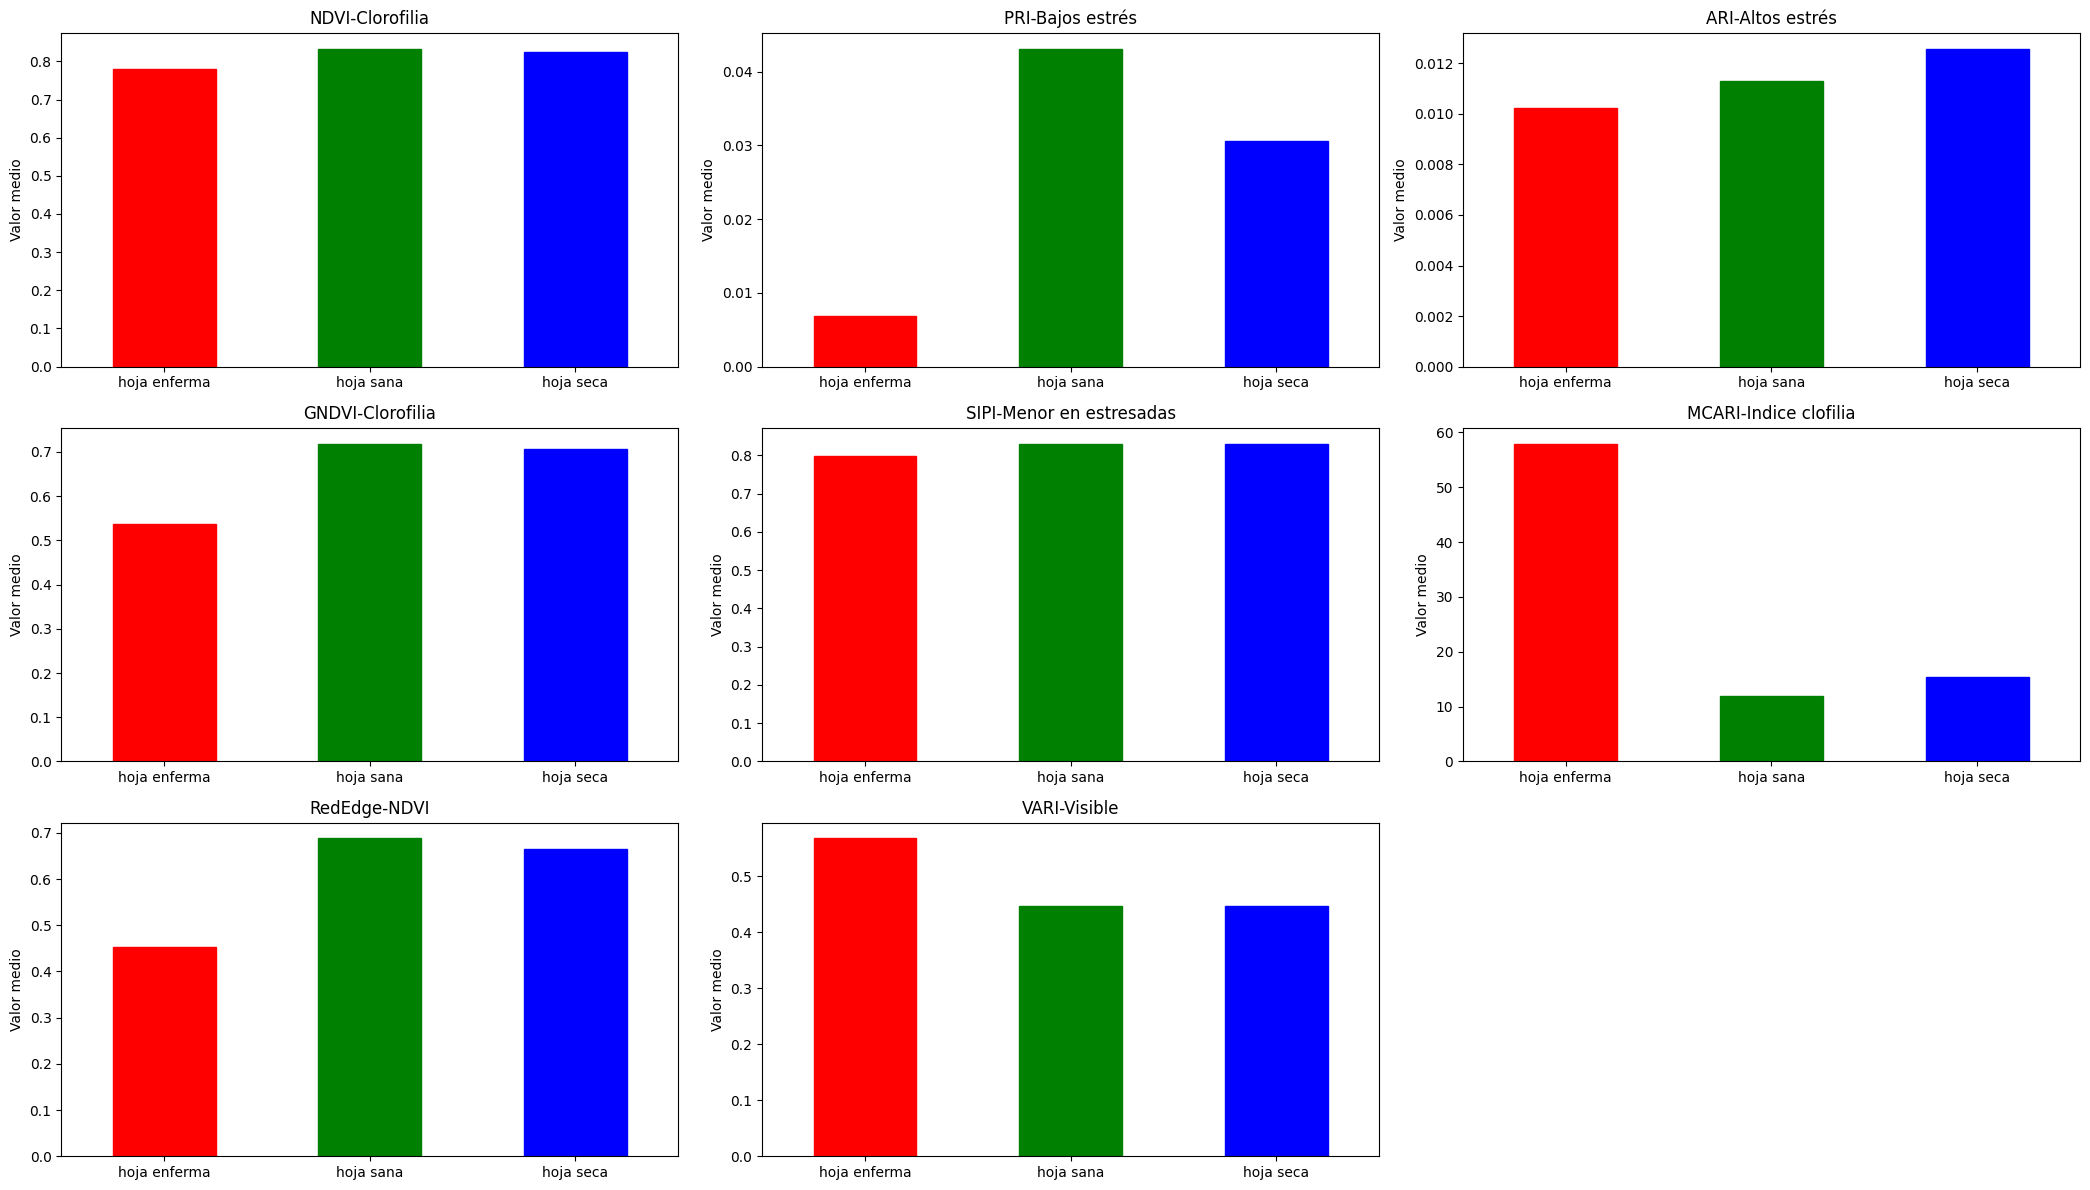

                              200.017  200.286  200.556  200.826  201.096  \
id_hoja                                                                     
hojaenferma.txt_08-02-2025      100.0    100.0    100.0    100.0    100.0   
hojaenfermaa.txt_06-02-2025     100.0    100.0    100.0    100.0    100.0   
hojaenfermaa.txt_061-02-2025    100.0    100.0    100.0    100.0    100.0   
hojaenfermaa.txt_062-02-2025    100.0    100.0    100.0    100.0    100.0   
hojaenfermaa.txt_07-02-2025     100.0    100.0    100.0    100.0    100.0   

                              201.365  201.635  201.905  202.174  202.444  \
id_hoja                                                                     
hojaenferma.txt_08-02-2025      100.0    100.0    100.0    100.0    100.0   
hojaenfermaa.txt_06-02-2025     100.0    100.0    100.0    100.0    100.0   
hojaenfermaa.txt_061-02-2025    100.0    100.0    100.0    100.0    100.0   
hojaenfermaa.txt_062-02-2025    100.0    100.0    100.0    100.0    100.0  

In [ ]:
import os
import matplotlib.pyplot as plt

output_dir = "graficas_indices"
os.makedirs(output_dir, exist_ok=True)

# 1) Cargar los datos
df = pd.read_csv("data/datos_hojas_procesado.csv", index_col=0)

# 2) Asegurar que las columnas espectrales sean float
def try_float(col):
    try:
        return float(col)
    except:
        return col

df.columns = [try_float(c) for c in df.columns]

# 3) Separar espectros y etiqueta
spectral_cols = [c for c in df.columns if isinstance(c, float)]
label_col     = [c for c in df.columns if not isinstance(c, float)][0]

# 4) Función para encontrar la λ más cercana
def find_nearest(cols, target):
    return min(cols, key=lambda x: abs(x - target))

# 5) Longitudes de onda clave
targets = [445, 531, 550, 570, 670, 680, 700, 750, 800]
λ = {w: find_nearest(spectral_cols, w) for w in targets}

# 6) Calcular los índices
df["NDVI-Clorofilia"]   = (df[λ[750]] - df[λ[670]]) / (df[λ[750]] + df[λ[670]])
df["PRI-Bajos estrés"]    = (df[λ[531]] - df[λ[570]]) / (df[λ[531]] + df[λ[570]])
df["ARI-Altos estrés"]    = (1.0/df[λ[550]]) - (1.0/df[λ[700]])
df["GNDVI-Clorofilia"]  = (df[λ[750]] - df[λ[550]]) / (df[λ[750]] + df[λ[550]])
df["SIPI-Menor en estresadas"]   = (df[λ[800]] - df[λ[445]]) / (df[λ[800]] + df[λ[680]])
df["MCARI-Indice clofilia"]  = ((df[λ[700]] - df[λ[670]]) - 0.2*(df[λ[700]] - df[λ[550]])) * (df[λ[700]]/df[λ[670]])
df["RedEdge-NDVI"] = (df[λ[750]] - df[λ[700]]) / (df[λ[750]] + df[λ[700]])

# NUEVO: Calcular VARI
df["VARI-Visible"] = (df[λ[550]] - df[λ[670]]) / (df[λ[550]] + df[λ[670]] - df[λ[445]])

# 7) Convertir etiqueta a categórica
df[label_col] = df[label_col].astype(str)

# 8) Calcular medias por clase
indices = [
    "NDVI-Clorofilia", "PRI-Bajos estrés", "ARI-Altos estrés",
    "GNDVI-Clorofilia", "SIPI-Menor en estresadas", "MCARI-Indice clofilia",
    "RedEdge-NDVI", "VARI-Visible"  # VARI añadido
]
means = df.groupby(label_col)[indices].mean()

# 9) Graficar barras en un grid 3×3 con colores personalizados
colores = {
    "hoja enferma": "red",
    "hoja sana": "green",
    "hoja seca": "blue"
}

fig, axes = plt.subplots(3, 3, figsize=(21, 12))
axes = axes.flatten()

for ax, idx in zip(axes, indices):
    # Obtener los colores para cada barra según la etiqueta
    bar_colors = [colores.get(label, "gray") for label in means.index]
    bars = means[idx].plot(kind='bar', ax=ax, color=bar_colors)
    ax.set_title(idx)
    ax.set_ylabel("Valor medio")
    ax.set_xlabel("")
    ax.set_xticklabels(means.index, rotation=0)

    # Guardar cada gráfico individualmente como JPG
    fig_ind, ax_ind = plt.subplots(figsize=(8, 6))  # Tamaño individual
    means[idx].plot(kind='bar', ax=ax_ind, color=bar_colors)
    ax_ind.set_title(idx)
    ax_ind.set_ylabel("Valor medio")
    ax_ind.set_xlabel("")
    ax_ind.set_xticklabels(means.index, rotation=0)

    # Guardar en JPG (calidad 90, formato ajustable)
    output_path = os.path.join(output_dir, f"{idx}.jpg")
    fig_ind.savefig(output_path, format='jpg', dpi=300, bbox_inches='tight')
    plt.close(fig_ind)  # Cierra la figura individual para liberar memoria

    # Asignar colores a cada barra individualmente (por si acaso)
    for i, (label, bar) in enumerate(zip(means.index, bars.patches)):
        bar.set_color(colores.get(label, "grey"))

# Ocultar ejes sobrantes si hay menos de 9 índices
for i in range(len(indices), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 10) Primeros datos del nuevo df
print(df.head())

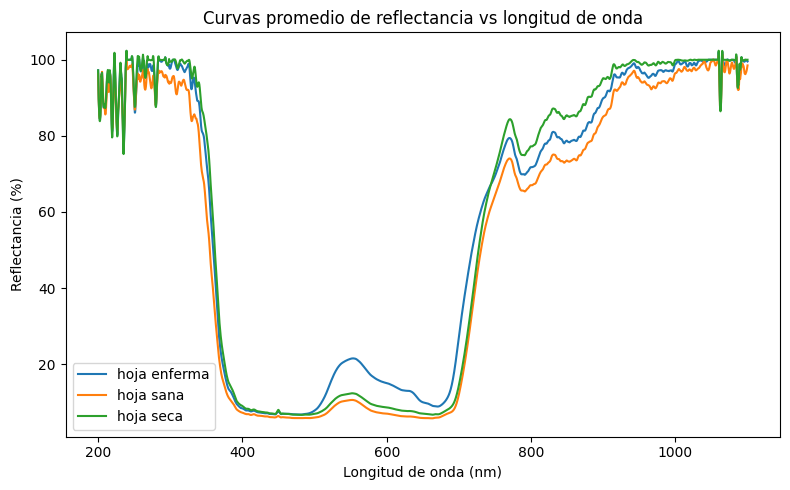

In [ ]:
# 1) Cargar los datos
df = pd.read_csv("data/datos_hojas_procesado.csv", index_col=0)

# 2) Asegurar que las columnas espectrales sean float
def try_float(col):
    try:
        return float(col)
    except:
        return col

df.columns = [try_float(c) for c in df.columns]

# 3) Separar nombres de columnas espectrales y etiqueta
spectral_cols = sorted([c for c in df.columns if isinstance(c, float)])
label_col     = [c for c in df.columns if not isinstance(c, float)][0]

# 4) Asegurarse de que la etiqueta sea categórica
df[label_col] = df[label_col].astype(str)

# 5) Calcular la media de reflectancia en cada λ para cada clase
#    Esto da un DataFrame indexado por λ, con columnas por clase
means_spec = df.groupby(label_col)[spectral_cols].mean().T

# 6) Graficar reflectancia vs longitud de onda
plt.figure(figsize=(8,5))
for clase in means_spec.columns:
    plt.plot(means_spec.index, means_spec[clase], label=clase)
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Reflectancia (%)")
plt.title("Curvas promedio de reflectancia vs longitud de onda")
plt.legend()
plt.tight_layout()
plt.show()


## Resultados

### Curvas de reflectancia
- Al graficar la reflectancia promedio vs. longitud de onda para cada condición (sana, enferma, deshidratada), se observa:
  - **Región roja (≈ 600–700 nm)**:  
    - Hojas sanas: absorción pronunciada (reflectancia baja).  
    - Hojas enfermas y deshidratadas: picos de reflectancia algo más elevados → menor actividad fotosintética.

---

### Índices vegetativos

| Índice   | Fórmula básica                                           | Interpretación general                                             |
|----------|----------------------------------------------------------|---------------------------------------------------------------------|
| **NDVI**   | (R<sub>750</sub> − R<sub>670</sub>) / (R<sub>750</sub> + R<sub>670</sub>) | Vigor y contenido de clorofila. Más alto = hoja más sana.          |
| **GNDVI**  | (R<sub>750</sub> − R<sub>550</sub>) / (R<sub>750</sub> + R<sub>550</sub>) | Similar al NDVI, más sensible a clorofila en verde.                |
| **PRI**    | (R<sub>531</sub> − R<sub>570</sub>) / (R<sub>531</sub> + R<sub>570</sub>) | Eficiencia fotosintética a corto plazo. Valores bajos → estrés.    |
| **ARI**    | (1/R<sub>550</sub>) − (1/R<sub>700</sub>)                       | Contenido de antocianinas (pigmentos de defensa). Más alto → estrés.|
| **SIPI**   | (R<sub>800</sub> − R<sub>445</sub>) / (R<sub>800</sub> + R<sub>680</sub>) | Relación carotenos–clorofilas. Menor en hojas estresadas.           |
| **MCARI**  | ((R<sub>700</sub>−R<sub>670</sub>) − 0.2·(R<sub>700</sub>−R<sub>550</sub>))·(R<sub>700</sub>/R<sub>670</sub>) | Índice específico para clorofila, corrige fondo de suelo.          |
| **RED EDGE**    | (R<sub>750</sub> − R<sub>700</sub>) / (R<sub>750</sub> + R<sub>700</sub>) | Vigorosidad de la planta, salud vegetal. Valores altos → mejor salud.    |

**Patrones observados**  
- **NDVI y GNDVI**:  
  - Máximos en hojas sanas  
  - Altos en deshidratadas  
  - Intermedios en enfermas  
  → Declive de vigor y contenido de clorofila.  
- **PRI**:  
  - Valores más bajos en hojas enfermas → menor eficiencia de uso de luz.  
  - Deshidratadas con valores intermedios.  
- **ARI**:  
  - Mayor en hojas deshidratas → acumulación de antocianinas frente al estrés.  
- **SIPI y MCARI**:  
  - Hojas sanas: valores altos  
  - Hojas enfermas: valores altos pero no tan extremos.
  - Deshidratadas: valores similares a las hojas sanas.
- **RED EDGE**:
  - Hojas sanas: valores altos  
  - Hojas enfermas: valores más bajos en la gráfica.
  - Deshidratadas: valores bajos pero no extremos.
---

## Interpretación biológica

- **Clorofila y vigor fotosintético**  
  Índices **NDVI**, **GNDVI** y **MCARI** cuantifican contenido y eficiencia de clorofila; su descenso señala desórdenes fisiológicos.
- **Estrés y pigmentos secundarios**  
  Índices **PRI** y **SIPI** detectan cambios rápidos en eficiencia fotosintética y balance carotenos/clorofilas; **ARI** mide síntesis de antocianinas como respuesta al daño.

> **Conclusión parcial:**  
> - Hojas sanas: alta reflectancia NIR y altos índices de clorofila.  
> - Hojas enfermas: bajo vigor (NDVI/GNDVI), baja eficiencia fotosintética (PRI) y mediana defensa química (ARI).  
> - Hojas deshidratadas: valores intermedios, pérdida moderada de agua y clorofila.

---

## Conclusiones

1. La combinación de curvas espectrales e índices vegetativos permite diferenciar claramente estados fisiológicos.  
2. **NDVI/GNDVI** y **MCARI** son robustos para medir contenido de clorofila y vigor.  
3. **PRI**, **ARI** y **SIPI** aportan información sobre estrés agudo y respuestas metabólicas.  
4. **RED EDGE** aporta una vista general de la salud vegetal de manera más clara para el lector.
5. Estos índices ofrecen una herramienta no invasiva y rápida para monitorear la salud y el estrés en cultivos de fresa.
6. El mejor clasificador de hojas de fresa es un clasificador SVM con hiperparámetros optimizados.


In [ ]:
from sklearn.metrics import classification_report

#reportes de cada modelo
reportes = {
    "LDA": classification_report(y_test, y_pred_lda, target_names=le.classes_, output_dict=True),
    "K-NN": classification_report(y_test, y_pred_knn, target_names=le.classes_, output_dict=True),
    "SVM": classification_report(y_test, y_pred_svm, target_names=le.classes_, output_dict=True),
    "Random Forest": classification_report(y_test, y_pred_rf, target_names=le.classes_, output_dict=True),
}

# DF para comparar métricas por modelo
Tabla_comparacion= pd.DataFrame({
    model: {
        "Accuracy": round(rep["accuracy"], 4),
        **{f"{metric}_{cls}": round(rep[cls][metric], 4)
           for cls in le.classes_
           for metric in ["precision", "recall", "f1-score"]}
    }
    for model, rep in reportes.items()
}).T


print(Tabla_comparacion)

               Accuracy  precision_hoja enferma  recall_hoja enferma  \
LDA              0.8710                  0.8571                 0.90   
K-NN             0.8548                  0.8824                 0.75   
SVM              0.9194                  1.0000                 0.95   
Random Forest    0.8387                  1.0000                 0.90   

               f1-score_hoja enferma  precision_hoja sana  recall_hoja sana  \
LDA                           0.8780               0.8824            0.7143   
K-NN                          0.8108               0.8182            0.8571   
SVM                           0.9744               0.9444            0.8095   
Random Forest                 0.9474               0.7727            0.8095   

               f1-score_hoja sana  precision_hoja seca  recall_hoja seca  \
LDA                        0.7895               0.8750            1.0000   
K-NN                       0.8372               0.8696            0.9524   
SVM            